# Homework Starter — Stage 10b: Time Series & Classification
Fill in the TODOs. Use your own dataset or adapt the synthetic generator below.

In [2]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
np.random.seed(7); sns.set(); plt.rcParams['figure.figsize']=(9,4)

## Option A: Use Your Own Data (Recommended)
Load your data here (ensure a DateTime index for time series).

In [5]:
# TODO: load your data
df = file_path = "prices_20250821-180122.parquet"
df = pd.read_parquet(file_path)
df['ret'] = df['aapl'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()

,date,aapl,VCNIX,ret,log_ret
0,2025-03-28,217.90,20.83,0.000000,0.000000
1,2025-03-31,222.13,20.83,0.019413,0.019227
2,2025-04-01,223.19,21.00,0.004772,0.004761
3,2025-04-02,223.89,21.16,0.003136,0.003131
4,2025-04-03,203.19,20.01,-0.092456,-0.097013


## Option B: Synthetic Generator (Use if you don't have data ready)

In [4]:
# Synthetic series with regimes & jumps
n=500
dates=pd.bdate_range('2025-03-28', periods=n)
mu = np.where(np.arange(n)<n//2, 0.0003, -0.0001)
sigma = np.where(np.arange(n)<n//2, 0.01, 0.015)
eps = np.random.normal(mu, sigma)
jumps = np.zeros(n); jump_days = np.random.choice(np.arange(20,n-20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0,0.05,size=len(jump_days))
rets = eps + jumps
price = 100*np.exp(np.cumsum(rets))
df = pd.DataFrame({'price':price}, index=dates)
df['ret'] = df['price'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()

,price,ret,log_ret
2025-03-28,101.735412,0.000000,0.000000
2025-03-31,101.292875,-0.004350,-0.004359
2025-04-01,101.356527,0.000628,0.000628
2025-04-02,101.800950,0.004385,0.004375
2025-04-03,101.031283,-0.007561,-0.007589


## Feature Engineering

In [6]:
# TODO: create at least two features
df['lag_1'] = df['ret'].shift(1)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
# Add your own:
# df['roll_vol_20'] = df['ret'].rolling(20).std().shift(1)
df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret']>0).astype(int)
df_feat = df.dropna().copy()
df_feat.head()

,date,aapl,VCNIX,ret,log_ret,lag_1,roll_mean_5,y_next_ret,y_up
5,2025-04-04,188.38,18.80,-0.072887,-0.075680,-0.092456,-0.013027,-0.036734,0
6,2025-04-07,181.46,18.83,-0.036734,-0.037426,-0.072887,-0.027605,-0.049818,0
7,2025-04-08,172.42,18.46,-0.049818,-0.051102,-0.036734,-0.038834,0.153288,1
8,2025-04-09,198.85,20.68,0.153288,0.142617,-0.049818,-0.049752,-0.042394,0
9,2025-04-10,190.42,19.81,-0.042394,-0.043319,0.153288,-0.019721,0.040594,1


## Split

In [7]:
# Time-aware split
cut=int(len(df_feat)*0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]
features=['lag_1','roll_mean_5']  # extend as you add features
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['y_next_ret'], test['y_next_ret']
y_tr_clf, y_te_clf = train['y_up'], test['y_up']

## Pipeline + Model (Choose one track below)

In [8]:
# Track 1: Forecasting returns
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)
mse = mean_squared_error(y_te_reg, pred)
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 0.017895239562431078


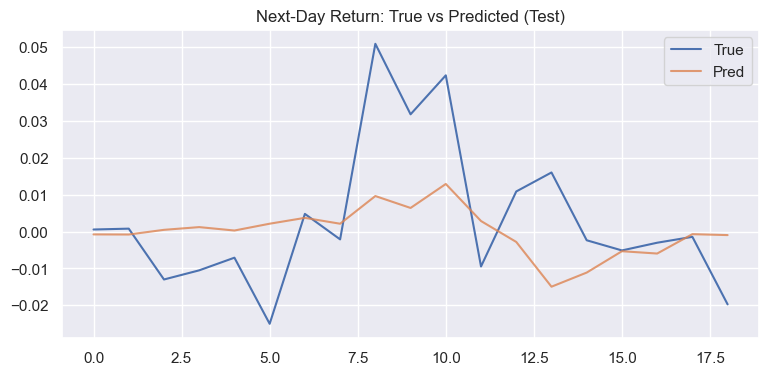

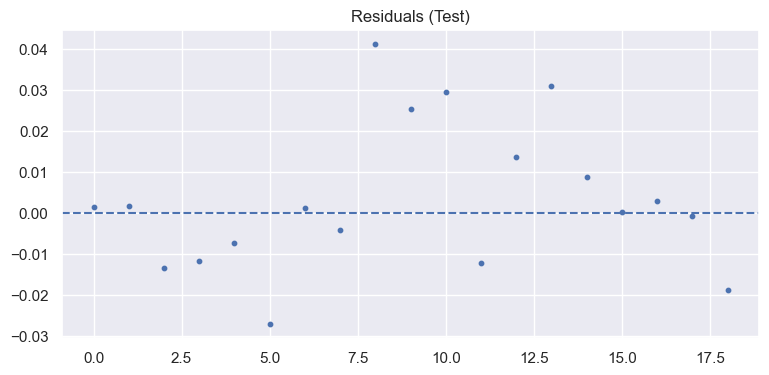

In [20]:
fig, ax = plt.subplots()
y_te_reg.reset_index(drop=True).plot(ax=ax, label='True')
pd.Series(pred).plot(ax=ax, label='Pred', alpha=0.8)
ax.set_title('Next-Day Return: True vs Predicted (Test)')
ax.legend(); plt.show()

resid = y_te_reg.values - pred
fig, ax = plt.subplots()
ax.scatter(range(len(resid)), resid, s=10)
ax.axhline(0, ls='--')
ax.set_title('Residuals (Test)'); plt.show()

              precision    recall  f1-score   support

           0       0.67      0.18      0.29        11
           1       0.44      0.88      0.58         8

    accuracy                           0.47        19
   macro avg       0.55      0.53      0.43        19
weighted avg       0.57      0.47      0.41        19



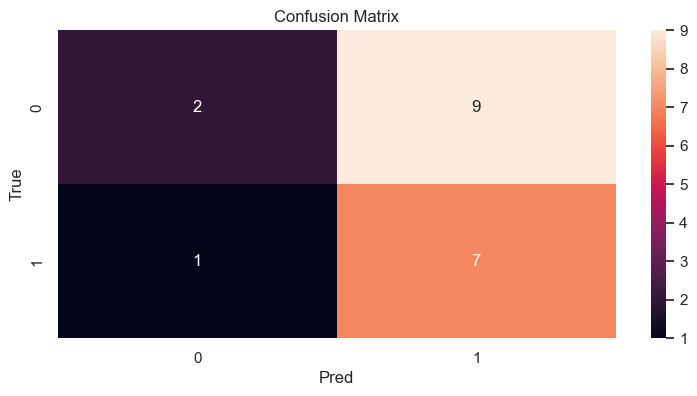

In [10]:
# Track 2: Classification (up/down)
clf = Pipeline([('scaler', StandardScaler()), ('logit', LogisticRegression(max_iter=1000))])
clf.fit(X_tr, y_tr_clf)
predc = clf.predict(X_te)
print(classification_report(y_te_clf, predc))
cm = confusion_matrix(y_te_clf, predc)
sns.heatmap(cm, annot=True, fmt='d'); plt.xlabel('Pred'); plt.ylabel('True');plt.title('Confusion Matrix'); plt.show()

## Interpretation (Markdown)
- The regression model has produced a forcast model for aapl stock return.
- The accuracy of the model do not perform very well. Assumption might be failed when I assuume that the stock return and the date would have a linear correlation.
- I could try more features and insert more data to increase the accuracy of the model.

### Save Notebook
Remember to save as `notebooks/modeling_<team>.ipynb`.